# Student Performance Prediction Using Data Science

## Step 1: Import Necessary Libraries

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Step 2: Load the Dataset

In [17]:
# Load dataset
df = pd.read_csv("Data Set-Student Performance Prediction.csv")  

# Display first 5 rows
print(df.head())

   S/N Gender  Age Location famsize Pstatus  Medu  Fedu  traveltime  \
0    1      F   13        U     GT3       A     4     4           2   
1    2      F   12        U     GT3       T     1     1           1   
2    3      F   10        U     LE3       T     1     1           1   
3    4      F   10        U     GT3       T     4     2           1   
4    5      F   11        U     GT3       T     3     3           1   

   studytime  ...  paid activities nursery higher internet famrel freetime  \
0          2  ...    no         no     yes    yes       no      4        3   
1          2  ...    no         no      no    yes      yes      5        3   
2          2  ...    no         no     yes    yes      yes      4        3   
3          3  ...    no        yes     yes    yes      yes      3        2   
4          2  ...    no         no     yes    yes       no      4        3   

  health  absences  Score  
0      3         4     22  
1      3         2     31  
2      3         6  

## Step 3: Handle Missing Values

In [18]:
# Fill missing numeric values with column mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Fill missing categorical values with mode
for col in df.select_dtypes(include=["object"]).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

## Step 4: Convert Categorical Data to Numerical

In [19]:
# Encode categorical variables
label_encoders = {}
for col in df.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Store encoders for future reference

## Step 5: Define Features & Target

In [20]:
# Convert 'Score' into categories (Low, Medium, High)
bins = [0, 40, 70, 100]  # Define score ranges
labels = ["Low", "Medium", "High"]

df["Score_Category"] = pd.cut(df["Score"], bins=bins, labels=labels)

# Encode categories into numbers
le = LabelEncoder()
df["Score_Category"] = le.fit_transform(df["Score_Category"])

# Define features (X) and target (y)
X = df.drop(columns=["S/N", "Score", "Score_Category"])  # Drop ID and original Score
y = df["Score_Category"]


## Step 6: Train-Test Split & Standardization

In [21]:
# Split dataset into training & testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numeric features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Step 7: Train the Model

In [22]:
# Train a classification model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

##  Step 8: Make Predictions & Evaluate

Unique values in y_test: {0, 1}
              precision    recall  f1-score   support

         Low       0.80      0.92      0.85        51
        High       0.33      0.14      0.20        14

    accuracy                           0.75        65
   macro avg       0.56      0.53      0.53        65
weighted avg       0.70      0.75      0.71        65



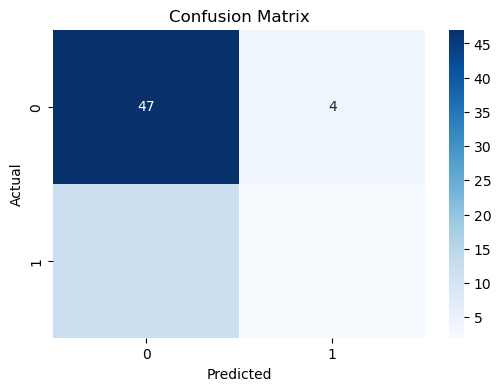

In [26]:
# Check unique values in y_test
print("Unique values in y_test:", set(y_test))

# Adjust target names based on unique classes in y_test
if len(set(y_test)) == 2:
    print(classification_report(y_test, y_pred, target_names=["Low", "High"]))
else:
    print(classification_report(y_test, y_pred, target_names=["Low", "Medium", "High"]))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Blues", fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()